# COURSE: A deep understanding of deep learning
## SECTION: Understand and design CNNs
### LECTURE: CodeChallenge: Autoencoders and occluded Gaussians
#### TEACHER: Mike X Cohen, sincxpress.com
##### COURSE URL: udemy.com/course/deeplearning_x/?couponCode=202401

In [28]:
# import libraries
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

# model summary info
from torchsummary import summary

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Create Gaussian blurs with varying widths and occluding bars

In [29]:
nGauss  = 1000
imgSize = 91

def generate_images(nGauss=1000,imgSize=91):
  x = np.linspace(-4,4,imgSize)
  X,Y = np.meshgrid(x,x)

  # vary the weights smoothly
  # each gaussian will have a different width
  widths = np.linspace(2,20,nGauss)

  # initialize tensor containing images
  images = torch.zeros(nGauss,1,imgSize,imgSize)
  imagesNoise = torch.zeros(nGauss,1,imgSize,imgSize)
  GNoise = np.zeros((imgSize,imgSize))

  for i in range(nGauss):

    # create the gaussian with random centers
    ro = 1.5*np.random.randn(2) # ro = random offset
    G  = np.exp( -( (X-ro[0])**2 + (Y-ro[1])**2) / widths[i] )
    
    # and add noise
    G  = G + np.random.randn(imgSize,imgSize)/5

    # add a random bar randomly
    i1 = np.random.choice(np.arange(2,28)) # starting point
    i2 = np.random.choice(np.arange(2,6)) # random width
    if np.random.randn()>0: # horizontal or vertical
      GNoise[i1:i1+i2,] = 1
    else:
      GNoise[:,i1:i1+i2] = 1
    
    # add to the tensor
    images[i,:,:,:] = torch.Tensor(G).view(1,imgSize,imgSize)
    imagesNoise[i,:,:,:] = images[i,:,:,:] + torch.Tensor(GNoise).view(1,imgSize,imgSize)
    GNoise = np.zeros((imgSize,imgSize))
  
  return images, imagesNoise

images, imagesNoise = generate_images(nGauss,imgSize)
testImages, testImagesNoise = generate_images(nGauss,imgSize)

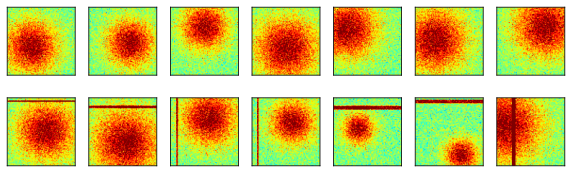

In [30]:
# visualize some images
fig,axs = plt.subplots(2,7,figsize=(10,3))

for i, ax in enumerate(axs[0, :7]):
  whichpic = np.random.randint(nGauss)
  G = np.squeeze(images[whichpic, :, :])
  ax.imshow(G, vmin=-1, vmax=1, cmap='jet')
  ax.set_xticks([])
  ax.set_yticks([])

for i, ax in enumerate(axs[1, :7]):
  whichpic = np.random.randint(nGauss)
  G = np.squeeze(imagesNoise[whichpic, :, :])
  ax.imshow(G, vmin=-1, vmax=1, cmap='jet')
  ax.set_xticks([])
  ax.set_yticks([])

plt.show()

# Create the DL model

In [31]:
# create a class for the model
def makeTheNet():

  class gausnet(nn.Module):
    def __init__(self):
      super().__init__()

      # The parameters are selected so that the input and output have the same size
      
      # encoding layer
      self.enc1 = nn.Sequential(
          nn.Conv2d(1,6,3,padding=1),
          nn.ReLU(),
          nn.MaxPool2d(2,2)
          )

      self.enc2 = nn.Sequential(
          nn.Conv2d(6,4,3,padding=1),
          nn.ReLU(),
          nn.MaxPool2d(2,2)  
          )
      
      # decoding layer
      self.dec = nn.Sequential(
          nn.ConvTranspose2d(4,6,3,2), # kernel 3, stride 2
          nn.ReLU()
          )
    
      self.dec2 = nn.Sequential(
          nn.ConvTranspose2d(6,1,3,2)
          # we don't need a nonlinearity here because it's the output
          )
      
    def forward(self,x):
      encoded1 = self.enc1(x)
      encoded2 = self.enc2(encoded1)
      decoded1 = self.dec(encoded2)
      decoded2 = self.dec2(decoded1)
      return encoded1, encoded2, decoded1, decoded2
  
  # create the model instance
  net = gausnet()
  
  # loss function
  lossfun = nn.MSELoss()

  # optimizer
  optimizer = torch.optim.Adam(net.parameters(),lr=.001)

  return net,lossfun,optimizer

 
torch.Size([10, 6, 45, 45])
torch.Size([10, 4, 22, 22])
torch.Size([10, 6, 45, 45])
torch.Size([10, 1, 91, 91])


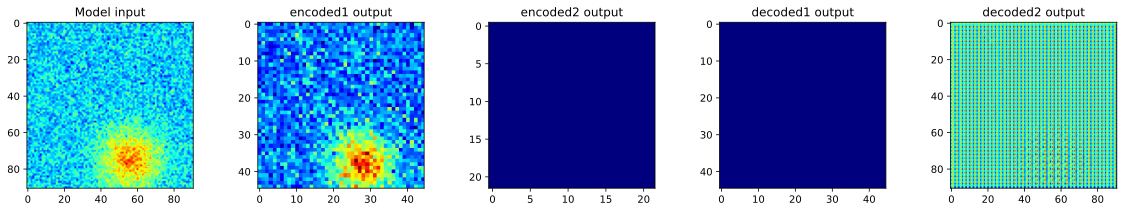

<Figure size 640x480 with 0 Axes>

In [32]:
# test the model with one batch
net,lossfun,optimizer = makeTheNet()

encoded1, encoded2, decoded1, decoded2 = net(images[:10,:,:,:])

# check size of output
print(' ')
print(encoded1.shape)
print(encoded2.shape)
print(decoded1.shape)
print(decoded2.shape)

# let's see how they look
fig,ax = plt.subplots(1,5,figsize=(20,3))
ax[0].imshow(torch.squeeze(images[0,0,:,:]).detach(),cmap='jet')
ax[0].set_title('Model input')
ax[1].imshow(torch.squeeze(encoded1[0,0,:,:]).detach(),cmap='jet')
ax[1].set_title('encoded1 output')
ax[2].imshow(torch.squeeze(encoded2[0,0,:,:]).detach(),cmap='jet')
ax[2].set_title('encoded2 output')
ax[3].imshow(torch.squeeze(decoded1[0,0,:,:]).detach(),cmap='jet')
ax[3].set_title('decoded1 output')
ax[4].imshow(torch.squeeze(decoded2[0,0,:,:]).detach(),cmap='jet')
ax[4].set_title('decoded2 output')
plt.show()

plt.tight_layout()
plt.show()

In [33]:
# count the total number of parameters in the model
summary(net,(1,imgSize,imgSize))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 91, 91]              60
              ReLU-2            [-1, 6, 91, 91]               0
         MaxPool2d-3            [-1, 6, 45, 45]               0
            Conv2d-4            [-1, 4, 45, 45]             220
              ReLU-5            [-1, 4, 45, 45]               0
         MaxPool2d-6            [-1, 4, 22, 22]               0
   ConvTranspose2d-7            [-1, 6, 45, 45]             222
              ReLU-8            [-1, 6, 45, 45]               0
   ConvTranspose2d-9            [-1, 1, 91, 91]              55
Total params: 557
Trainable params: 557
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.03
Forward/backward pass size (MB): 1.24
Params size (MB): 0.00
Estimated Total Size (MB): 1.27
---------------------------------------------------

# Create a function that trains the model

In [34]:
# a function that trains the model

def function2trainTheModel():

  # number of epochs
  numepochs = 500
  
  # create a new model
  net,lossfun,optimizer = makeTheNet()

  # initialize losses
  losses = torch.zeros(numepochs)
  testLosses = torch.zeros(numepochs)
  accuracy = torch.zeros(numepochs)
  testAccuracy = torch.zeros(numepochs)

  # loop over epochs
  # We don't use a dataloader here, but we pick a random set of images (32) at each epoch
  for epochi in range(numepochs):

    # pick a set of images at random
    pics2use = np.random.choice(nGauss,size=32,replace=False)
    X = imagesNoise[pics2use,:,:,:]
    XNoNoise = images[pics2use,:,:,:]

    # forward pass and loss
    _, _, _, decoded2 = net(X)
    loss = lossfun(decoded2,XNoNoise)

    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # add loss
    losses[epochi] = loss.item()

    # compute accuracy between images with and without noise
    for i, image in enumerate(X):
      y = images[pics2use[i],:,:,:]
      yhat = decoded2[i]
      # compute correlation
      y_flat = y.view(y.size(0), -1).detach() # flatten the images. Size 32x(whatever the size)
      yhat_flat = yhat.view(yhat.size(0), -1).detach()
      corr = np.corrcoef(y_flat, yhat_flat)
      # the correlation matrix is 2x2, we want the off-diagonal element
      corr = corr[0,1]
      # take the average correlation across all images
      if i == 0:
        avg_corr = corr
      else:
        avg_corr += corr
    accuracy[epochi] = avg_corr.item()/32
    
    with torch.no_grad():
      # test the model on some test images
      # pick a set of images at random
      pics2use = np.random.choice(nGauss,size=32,replace=False)
      X = testImages[pics2use,:,:,:]
      XNoNoise = testImagesNoise[pics2use,:,:,:]
      _, _, _, testDecoded = net(X)
      testLoss = lossfun(testDecoded,XNoNoise)
      testLosses[epochi] = testLoss.item()

      for i, image in enumerate(X):
        y = testImages[pics2use[i],:,:,:]
        yhat = testDecoded[i]
        # compute correlation
        y_flat = y.view(y.size(0), -1).detach()
        yhat_flat = yhat.view(yhat.size(0), -1).detach()
        corr = np.corrcoef(y_flat, yhat_flat)
        # the correlation matrix is 2x2, we want the off-diagonal element
        corr = corr[0,1]
        # take the average correlation across all images
        if i == 0:
          avg_corr = corr
        else:
          avg_corr += corr
      testAccuracy[epochi] = avg_corr.item()/32

  # end epochs

  return losses, testLosses, accuracy, testAccuracy, net

# Run the model and show the results!

In [35]:
# test the model on a bit of data
losses,testLosses,accuracy, testAccuracy, net = function2trainTheModel()

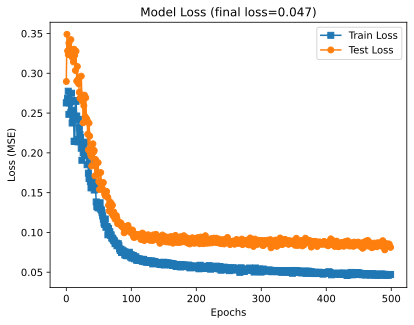

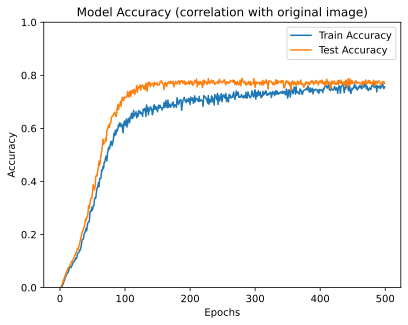

In [40]:
# First figure: Losses
plt.figure()
plt.plot(losses, 's-', label='Train Loss')
plt.plot(testLosses, 'o-', label='Test Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Model Loss (final loss=%.3f)' % losses[-1])
plt.show()

# Second figure: Accuracy
plt.figure()
plt.plot(accuracy, '-', label='Train Accuracy')
plt.plot(testAccuracy, '-', label='Test Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy (correlation with original image)')
plt.ylim([0,1])
plt.show()

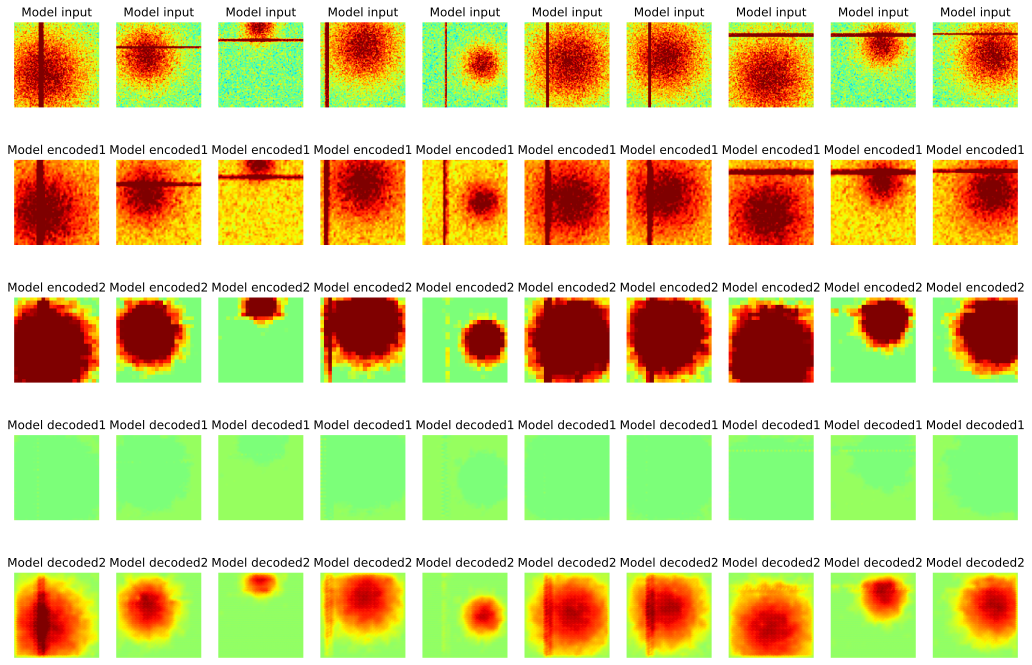

In [37]:
# visualize some images

pics2use = np.random.choice(nGauss,size=32,replace=False)
X = testImagesNoise[pics2use,:,:,:]
encoded1, encoded2, decoded1, decoded2 = net(X)

fig,axs = plt.subplots(5,10,figsize=(18,12))

for i in range(10):
  
  inputImg = torch.squeeze( X[i,0,:,:] ).detach() #this removes the channel dimension
  encoded1Img = torch.squeeze(encoded1[i,0,:,:]).detach() #this removes the channel dimension
  encoded2Img = torch.squeeze(encoded2[i,0,:,:]).detach() #this removes the channel dimension
  decoded1Img = torch.squeeze(decoded1[i,0,:,:]).detach() #this removes the channel dimension
  decoded2Img = torch.squeeze(decoded2[i,0,:,:]).detach() #this removes the channel dimension
  
  axs[0,i].imshow(inputImg,vmin=-1,vmax=1,cmap='jet')
  axs[0,i].axis('off')
  axs[0,i].set_title('Model input')

  axs[1,i].imshow(encoded1Img,vmin=-1,vmax=1,cmap='jet')
  axs[1,i].axis('off')
  axs[1,i].set_title('Model encoded1')

  axs[2,i].imshow(encoded2Img,vmin=-1,vmax=1,cmap='jet')
  axs[2,i].axis('off')
  axs[2,i].set_title('Model encoded2')

  axs[3,i].imshow(decoded1Img,vmin=-1,vmax=1,cmap='jet')
  axs[3,i].axis('off')
  axs[3,i].set_title('Model decoded1')

  axs[4,i].imshow(decoded2Img,vmin=-1,vmax=1,cmap='jet')
  axs[4,i].axis('off')
  axs[4,i].set_title('Model decoded2')

plt.show()

# Additional explorations

In [38]:
# 1) There are no test data here, so how do you know whether the model overfit the training set? Fortunately, you can
#    simply create as much new data as you want! That's one of the advantages of generating data ;)
#    Generate a new dataset to use as a test set. How does the MSE loss compare on the test set? Did we overfit here?
#
#    Clearly overfitted. But now it works? Maybe I had a bug before.
# 
# 2) The code here uses MaxPool. Are the results noticeably different if you use AvgPool instead?
#
#    Honestly, not much. 
# 
# 3) The final output doesn't have a nonlinearity (e.g., relu, sigmoid, tanh). Does it need one? Would that help? What
#    are some arguments for and against having a nonlinear activation function on the output of the decover? Try adding
#    one and see if it improves (via the final loss and visual inspection) the result.
#
#    I don't think it needs one, but the results are very similar.
# 
# 4) I mentioned in the lecture "What are autoencoders and what do they do?" (section "Autoencoders") that BCEloss can be
#    used when the data are between 0 and 1. Normalize the images so they are appropriately scaled, and then use BCEloss
#    instead of MSEloss (does anything else in the model architecture need to change?). Which loss function gives a 
#    better result?
# 